### Task_1_eda_preprocessing

In [ ]:
# Set path
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
# 2: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.preprocessing import (ComplaintDataLoader,filter_products,
    remove_missing_narratives, clean_text)

In [6]:
#  Load and filter data
df = pd.read_csv('../data/raw/complaints.csv')

C:\Users\ssss\AppData\Local\Temp\ipykernel_12860\1324797555.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv')


In [8]:
# Filter 5 products and drop missing narratives
df = filter_products(df)
df = remove_missing_narratives(df)

In [9]:
# Clean text and compute length
df['cleaned_narrative'] = df['Consumer complaint narrative'].apply(clean_text)
df['narrative_length'] = df['cleaned_narrative'].apply(lambda x: len(x.split()))

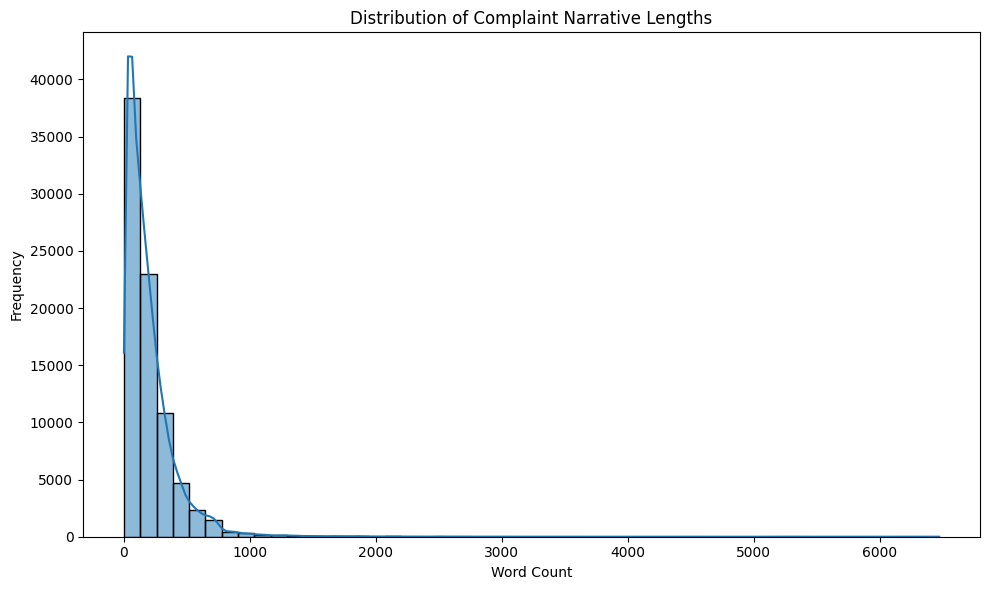

In [11]:
# Plot length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["narrative_length"], bins=50, kde=True)
plt.title("Distribution of Complaint Narrative Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/narrative_lengths.png")
plt.show()

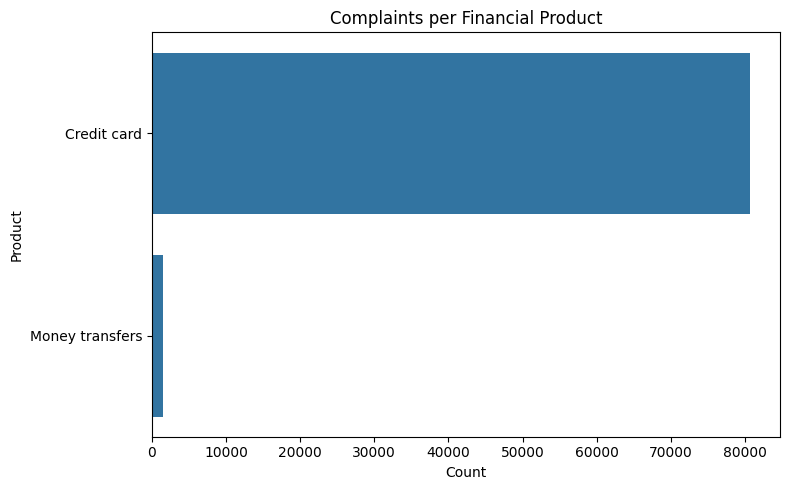

In [12]:
# Plot complaints per product
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Product', order=df['Product'].value_counts().index)
plt.title("Complaints per Financial Product")
plt.xlabel("Count")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../reports/product_distribution.png")
plt.show()

In [13]:
# Save final dataset
df.to_csv("../data/filtered_complaints.csv", index=False)
print("Cleaned data saved to data/filtered_complaints.csv")

Cleaned data saved to data/filtered_complaints.csv


In [7]:
'''
## Task 1: EDA & Preprocessing Summary

From the raw dataset `complaints.csv`, we extracted complaints from five financial product categories:

- Credit card
- Personal loan
- BNPL
- Savings account
- Money transfers

Records without complaint narratives were removed. Cleaned text was prepared for semantic embedding using lowercasing, punctuation removal, and whitespace normalization.

Complaint lengths range mostly between  and words. The highest complaint volumes are in Credit Cards and BNPL products.

The cleaned dataset is saved to `data/filtered_complaints.csv`.

'''

'\n## Task 1: EDA & Preprocessing Summary\n\nFrom the raw dataset `complaints.csv`, we extracted complaints from five financial product categories:\n\n- Credit card\n- Personal loan\n- BNPL\n- Savings account\n- Money transfers\n\nRecords without complaint narratives were removed. Cleaned text was prepared for semantic embedding using lowercasing, punctuation removal, and whitespace normalization.\n\nComplaint lengths range mostly between  and words. The highest complaint volumes are in Credit Cards and BNPL products.\n\nThe cleaned dataset is saved to `data/filtered_complaints.csv`.\n\n'